# Titanic Dataset Analysis
This notebook will walk through the steps of loading, cleaning, and performing basic exploratory data analysis on the Titanic dataset.

## Import necessary libraries

In [20]:
import pandas as pd

## <br>Step 1: Load the dataset
We use pandas to load the Titanic dataset into a DataFrame.

In [21]:
# Assuming the CSV is in the same directory as this notebook
csv_path = 'Titanic-Dataset.csv'
df = pd.read_csv(csv_path)
print("Dataset loaded successfully!")

# Display general information
print("\nDataset Info:")
df.info()

# Display first 5 rows
print("\nFirst 5 rows:")
df.head()

Dataset loaded successfully!

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

First 5 rows:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## <br>Step 2: Check for Duplicate Rows

In [22]:
print("\nChecking for duplicate rows:")
print(df.duplicated())
print("\nNumber of duplicate rows: ", df.duplicated().sum())


Checking for duplicate rows:
0      False
1      False
2      False
3      False
4      False
       ...  
886    False
887    False
888    False
889    False
890    False
Length: 891, dtype: bool

Number of duplicate rows:  0


## <br>Step 3: Identify Column Data Types

In [23]:
cat_col = [col for col in df.columns if df[col].dtype == 'object']
num_col = [col for col in df.columns if df[col].dtype != 'object']

print("\n")
print("Categorical Columns: ", cat_col)
print("Numerical Columns:   ", num_col)



Categorical Columns:  ['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']
Numerical Columns:    ['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']


## <br>Step 4: Analyze Categorical Columns

In [24]:
print(df[cat_col].nunique())
print("\nCategorical Columns Size: ", df[cat_col].size)

Name        891
Sex           2
Ticket      681
Cabin       147
Embarked      3
dtype: int64

Categorical Columns Size:  4455


## <br>Step 5: Calculate Missing Values as Percentage

In [25]:
print(df.isnull().sum(), "\n")
print(df.shape)
print(df.shape[0], "\n")
print(round(df.isnull().sum() / df.shape[0] * 100, 2), "\n")

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64 

(891, 12)
891 

PassengerId     0.00
Survived        0.00
Pclass          0.00
Name            0.00
Sex             0.00
Age            19.87
SibSp           0.00
Parch           0.00
Ticket          0.00
Fare            0.00
Cabin          77.10
Embarked        0.22
dtype: float64 



## <br>Step 6: Drop Irrelevant or Data-Heavy Missing Columns
We drop `Cabin`, `Ticket`, and `Name` columns. Then handle missing `Embarked` and `Age` values.


In [26]:
df1 = df.drop(['Cabin', 'Ticket', 'Name'], axis=1)
df1.dropna(subset=['Embarked'], inplace=True)
df1['Age'] = df1['Age'].fillna(df1['Age'].mean())
df1.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,0,3,male,22.0,1,0,7.2500,S
1,2,1,1,female,38.0,1,0,71.2833,C
2,3,1,3,female,26.0,0,0,7.9250,S
3,4,1,1,female,35.0,1,0,53.1000,S
4,5,0,3,male,35.0,0,0,8.0500,S


## <br>Step 7: Detect Outliers with Box Plot
IQR:     https://www.geeksforgeeks.org/maths/interquartile-range/

BoxPlot: https://www.geeksforgeeks.org/machine-learning/box-plot/

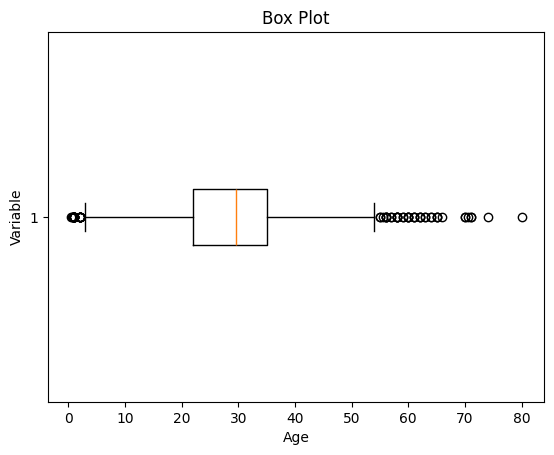

In [27]:
import matplotlib.pyplot as plt

df3 = df1.copy()
before_outliers_cleaning = df1.copy()

plt.boxplot(df3['Age'], vert=False)
plt.ylabel('Variable')
plt.xlabel('Age')
plt.title('Box Plot')
plt.show()

## <br>Step 8: Calculate Outlier Boundaries and Remove Them
Define bounds as mean ± 2 * std for outlier detection.

In [28]:
mean = df1["Age"].mean()
std = df1["Age"].std()
print("Mean: ", round(mean, 2))
print("Standard Deviation: ", round(std, 2))

lower_bound = mean - 2 * std
upper_bound = mean + 2 * std
print("Lower Bound: ", round(lower_bound, 2))
print("Upper Bound: ", round(upper_bound, 2))

outliears = df1[(df1["Age"] < lower_bound) | (df1["Age"] > upper_bound)]
print("Number of outliers in Age: ", outliears["Age"].count())

df2 = df1[(df1["Age"] >= lower_bound) & (df1["Age"] <= upper_bound)]
df2.head()

Mean:  29.64
Standard Deviation:  12.97
Lower Bound:  3.71
Upper Bound:  55.58
Number of outliers in Age:  68


,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,0,3,male,22.0,1,0,7.2500,S
1,2,1,1,female,38.0,1,0,71.2833,C
2,3,1,3,female,26.0,0,0,7.9250,S
3,4,1,1,female,35.0,1,0,53.1000,S
4,5,0,3,male,35.0,0,0,8.0500,S


## <br> Step 9: Impute Missing Data Again if Any
fillna() applied again on filtered data to handle any remaining missing values.

In [29]:
df3 = df2.fillna(df2["Age"].mean())
print(df3.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Sex            0
Age            0
SibSp          0
Parch          0
Fare           0
Embarked       0
dtype: int64


### Comparing Results

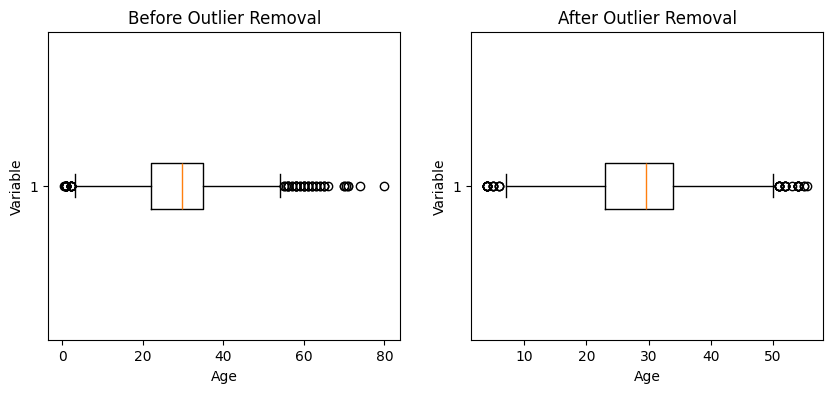

In [30]:
before_outliers_cleaning = df1.copy()

# The first two parameters (1, 2) specify the number of rows and columns of subplots, respectively.
# figsize specifies the overall size of the figure in inches.
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].boxplot(before_outliers_cleaning['Age'], vert=False)
axes[0].set_title('Before Outlier Removal')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Variable')

axes[1].boxplot(df3['Age'], vert=False)
axes[1].set_title('After Outlier Removal')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Variable')

plt.show()

## <br>Step 10: Recalculate Outlier Bounds and Remove Outliers from the Updated Data

<ul class="marker:text-quiet list-disc"><li value="1"><b><strong>mean = df3['Age'].mean()</strong></b><span>: Calculates the average (mean) value of the&nbsp;Age&nbsp;column in the DataFrame&nbsp;df3.</span></li><li value="2"><b><strong>std = df3['Age'].std()</strong></b><span>: Computes the standard deviation (spread or variability) of the&nbsp;Age&nbsp;column in&nbsp;df3.</span></li><li value="3"><b><strong>lower_bound = mean - 2 * std</strong></b><span>: Defines the lower limit for acceptable&nbsp;Age&nbsp;values, set as two standard deviations below the mean.</span></li><li value="4"><b><strong>upper_bound = mean + 2 * std</strong></b><span>: Defines the upper limit for acceptable&nbsp;Age&nbsp;values, set as two standard deviations above the mean.</span></li><li value="5"><b><strong>df4 = df3[(df3['Age'] &gt;= lower_bound) &amp; (df3['Age'] &lt;= upper_bound)]</strong></b><span>: Creates a new DataFrame&nbsp;df4&nbsp;by selecting only rows where the&nbsp;Age&nbsp;value falls between the lower and upper bounds, effectively removing outlier ages outside this range.</span></li></ul>

Mean after outlier removal:  29.14
Standard Deviation after outlier removal:  10.08
Lower Bound after outlier removal:  8.98
Upper Bound after outlier removal:  49.3


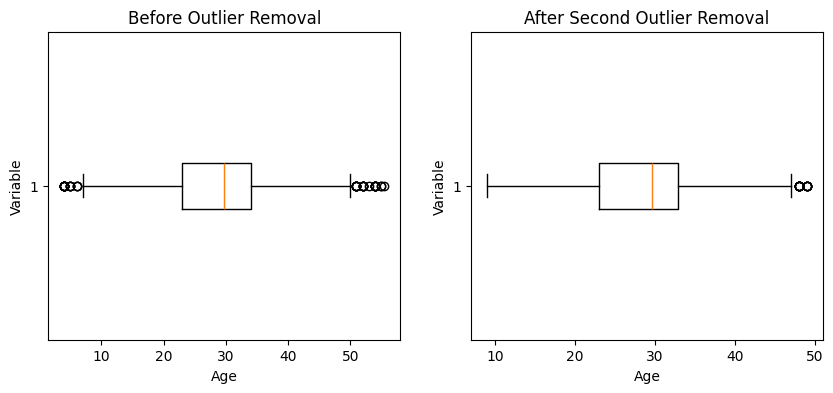

In [31]:
mean = df3["Age"].mean()
std = df3["Age"].std()
print("Mean after outlier removal: ", round(mean, 2))
print("Standard Deviation after outlier removal: ", round(std, 2))

lower_bound = mean - 2 * std
upper_bound = mean + 2 * std
print("Lower Bound after outlier removal: ", round(lower_bound, 2))
print("Upper Bound after outlier removal: ", round(upper_bound, 2))

df4 = df3[(df3["Age"] >= lower_bound) & (df3["Age"] <= upper_bound)]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].boxplot(df3['Age'], vert=False)
axes[0].set_title('Before Outlier Removal')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Variable')

axes[1].boxplot(df4['Age'], vert=False)
axes[1].set_title('After Second Outlier Removal')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Variable')
plt.show()

### This method is called the "Z-score method" or "Standard Deviation method" for outlier detection. 
1. It identifies outliers based on how many standard deviations a data point is from the mean. 
2. Typically, data points that fall beyond a certain number of standard deviations (commonly 2 or 3) from the mean are considered outliers.

<b>Question:</b> Why we have used z-score method to clean outliers instead of IQR in step-10?

## <br>Step 11: Data validation and verification
### Data Validation, Verification, and Feature Selection

**Data validation and verification**  
This means checking that the data is correct and consistent, often by comparing it with trusted sources or expert knowledge.

**Machine Learning Feature Setup**  
For machine learning, we split the data into:

- **Independent features** (inputs the model uses to make predictions)
- **Target variable** (what we want to predict)

**In this example:**

- **Independent features:** `Sex`, `Age`, `SibSp`, `Parch`, `Fare`, `Embarked`  
- **Target variable:** `Survived`  
- **Excluded feature:** `PassengerId` (it doesn’t affect survival)


In [32]:
X = df3[['Pclass','Sex','Age', 'SibSp','Parch','Fare','Embarked']]
Y = df3['Survived']

print(X.head(), "\n")
print(Y.head())

   Pclass     Sex   Age  SibSp  Parch     Fare Embarked
0       3    male  22.0      1      0   7.2500        S
1       1  female  38.0      1      0  71.2833        C
2       3  female  26.0      0      0   7.9250        S
3       1  female  35.0      1      0  53.1000        S
4       3    male  35.0      0      0   8.0500        S 

0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64


## <br> Step 12: Data formatting

### Data Formatting: Scaling and Normalization

**Data formatting**  
Data formatting means converting data into a standard format or structure that algorithms can easily process.

We will focus on two common techniques: **Scaling** and **Normalization**.

---

### Scaling

Scaling changes the values of features to a specific range without altering the shape of the original distribution.  
It is useful when features have different scales and some algorithms are sensitive to the magnitude of the values.

#### Common Scaling Method

1. **Min-Max Scaling**  
   - Rescales values to a specific range, usually **0 to 1**.  
   - Preserves the original distribution.  
   - Maps the **minimum value** to 0 and the **maximum value** to 1.


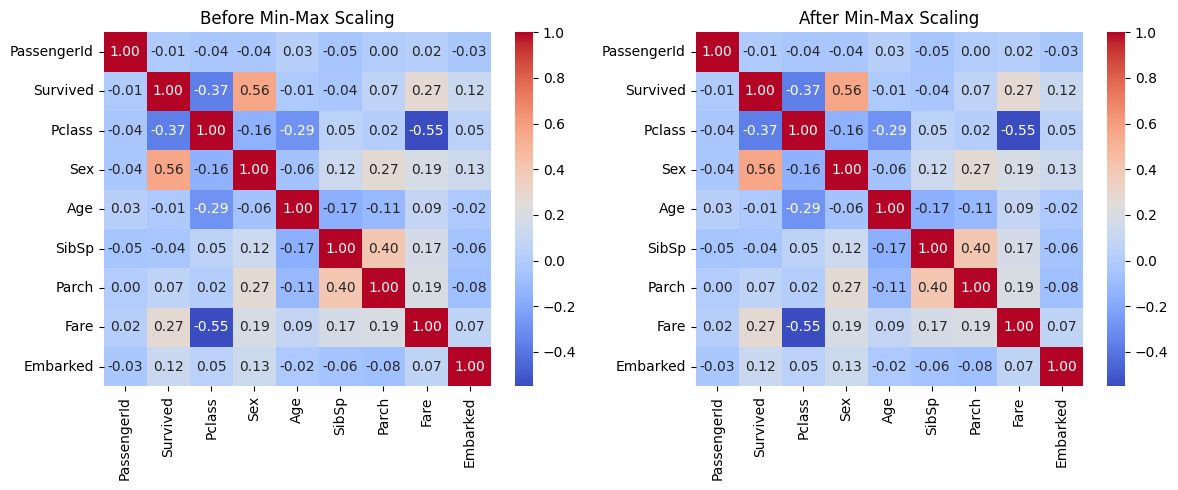

In [44]:
'''
    Seaborn is a Python data visualization library based on Matplotlib that provides a high-level 
    interface for drawing attractive and informative statistical graphics.

    Scikit-learn (sklearn) is a popular Python library for machine learning. 
    It provides easy-to-use tools for data analysis, including algorithms for classification, 
    regression, clustering, dimensionality reduction, and preprocessing. 
    Built on NumPy, SciPy, and Matplotlib, it integrates well with other Python scientific libraries.
'''
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

# --- Convert categorical variables to numerical ---
df3_encoded = df3.copy()
df3_encoded['Sex'] = df3_encoded['Sex'].map({'male': 0, 'female': 1})
df3_encoded['Embarked'] = df3_encoded['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

# --- Correlation matrix BEFORE Min-Max scaling ---
correlation_before = df3_encoded.corr()

# --- Apply Min-Max Scaling ---
scaler = MinMaxScaler(feature_range=(0, 1))
num_col = [col for col in df3_encoded.columns if df3_encoded[col].dtype != 'object']
df3_scaled = df3_encoded.copy()
df3_scaled[num_col] = scaler.fit_transform(df3_scaled[num_col])

# --- Correlation matrix AFTER Min-Max scaling ---
correlation_after = df3_scaled.corr()

# --- Plot side by side ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(correlation_before, annot=True, cmap='coolwarm', fmt=".2f", ax=axes[0])
axes[0].set_title('Before Min-Max Scaling')

sns.heatmap(correlation_after, annot=True, cmap='coolwarm', fmt=".2f", ax=axes[1])
axes[1].set_title('After Min-Max Scaling')

plt.tight_layout()
plt.show()


### 2. Standardization (Z-score Scaling)

Standardization transforms the values to have a **mean of 0** and a **standard deviation of 1**.  
It centers the data around the mean and scales it based on the standard deviation.  

Standardization is useful for algorithms that assume a Gaussian distribution or require features to have **zero mean** and **unit variance**.

The formula for Z-score standardization is:

$$
Z = \frac{X - \mu}{\sigma}
$$

Where:  
- $X$ = Data  
- $\mu$ = Mean value of $X$  
- $\sigma$ = Standard deviation of $X$
